In [1]:
import numpy as np
import matplotlib.pyplot as plt


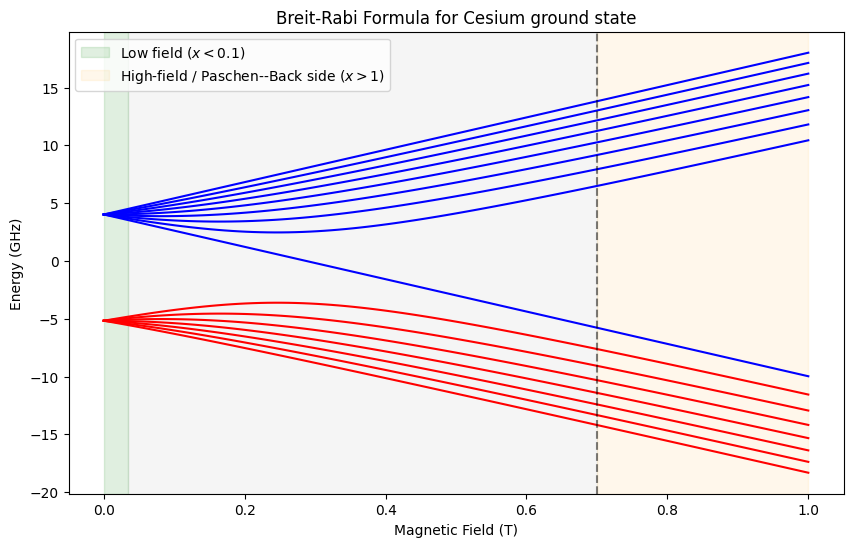

In [ ]:
#Q1
%matplotlib inline
# function to calculate Breit-Rabi formula
MU_B = 9.274009994e-24  # Bohr magneton in J/T
I = 7/2  # Nuclear spin for Cesium
H = 6.62607015e-34  # Planck's constant in J*s
to_J = 1e9 * H  # Conversion factor from GHz to J
g_S = 2.00231930436256  # Lande g-factor for electron
g_L = 1.0  # Lande g-factor for orbital angular momentum

#for 6S1/2 state of Cesium, J = 1/2, L = 0, S = 1/2
J = 1/2
L = 0
S = 1/2
g_J = g_L* (J*(J+1) + L*(L+1) - S*(S+1)) / (2*J*(J+1)) + g_S * (J*(J+1) - L*(L+1) + S*(S+1)) / (2*J*(J+1))
g_I = -0.00039885395 # Lande g-factor for Cesium nucleus, ref: Steck
def breit_rabi(B, m_F, E_hfs, branch=1):
    x = MU_B * (g_J - g_I) * B / (E_hfs*to_J)
    sqrt_term = np.sqrt(1 + 2 * m_F * x / (I + 1/2) + x**2)
    if abs(m_F) == I + J:
        sqrt_term = 1 + np.sign(m_F) * x

    return E_hfs * (-1 / (2 * (2*I+1)) + MU_B * g_I * m_F * B / (E_hfs*to_J) + branch * 1/2 * sqrt_term)

B = np.linspace(0, 1, 100)  # Magnetic field in Tesla
E_hfs = 9.1926317702  # Hyperfine splitting of clock transition (in GHz)

F_upper = I + J    # 4
F_lower = I - J    # 3

mF_upper = np.arange(-F_upper, F_upper + 1)
mF_lower = np.arange(-F_lower, F_lower + 1)

fig, ax = plt.subplots(figsize=(10, 6))
for mF in mF_upper:
    plt.plot(B, breit_rabi(B, mF, E_hfs, branch=1), color='blue')

for mF in mF_lower:
    plt.plot(B, breit_rabi(B, mF, E_hfs, branch=-1), color='red')

B0=0.7
B_low = 0.05 * B0
B_cross = B0

ax.axvspan(
    0,
    B_low,
    alpha=0.12,
    color="green",
    label=r"Low field ($x<0.1$)"
)

ax.axvspan(
    B_low,
    B_cross,
    alpha=0.08,
    color="gray"
)

ax.axvspan(
    B_cross,
    B.max(),
    alpha=0.08,
    color="orange",
    label=r"High-field / Paschen--Back side ($x>1$)"
)

ax.axvline(
    B0,
    linestyle="--",
    color="black",
    alpha=0.5
)

plt.xlabel('Magnetic Field (T)')
plt.ylabel('Energy (GHz)')
plt.title('Breit-Rabi Formula for Cesium ground state')
plt.legend()
plt.show()

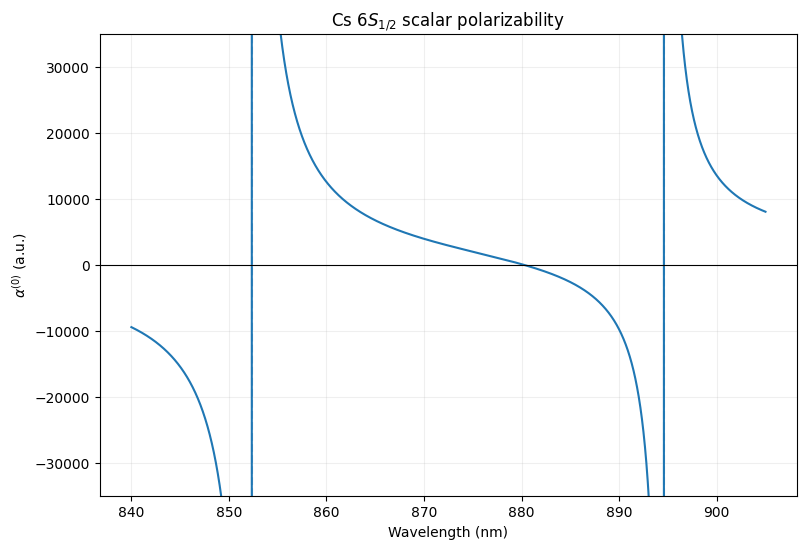

2668.509370961231


In [ ]:
#Q2 part 2
h = 6.62607015e-34
c = 299792458
e = 1.602176634e-19
a_0 = 5.29177210903e-11

# transition wavelengths
omega_D1 = 2*np.pi*335.116048e12
omega_D2 = 2*np.pi*351.725718e12
lambda_D1 = 894.592959e-9
lambda_D2 = 852.347275e-9

# standard reduced matrix elements
d1 = 3.186*e*a_0
d2 = 4.484*e*a_0

def alpha_ground(wavelength_nm):
    wavelength = wavelength_nm * 1e-9
    omega = 2 * np.pi * c / wavelength
    return (4*np.pi/(3*h)) * (d1**2 * omega_D1 / (omega_D1**2 - omega**2) + d2**2 * omega_D2 / (omega_D2**2 - omega**2)) * 6.065e40


lam = np.linspace(840, 905, 5000)

alpha = alpha_ground(lam)

# remove points extremely close to poles
alpha[np.abs(2*np.pi*c/(lam*1e-9) - lambda_D1*1e9) < 0.05] = np.nan
alpha[np.abs(2*np.pi*c/(lam*1e-9) - lambda_D2*1e9) < 0.05] = np.nan

plt.figure(figsize=(9,6))

plt.plot(lam, alpha)

plt.axvline(lambda_D1*1e9, ls="--", alpha=0.5)
plt.axvline(lambda_D2*1e9, ls="--", alpha=0.5)
plt.axhline(0, color="black", lw=0.8)

plt.xlabel("Wavelength (nm)")
plt.ylabel(r"$\alpha^{(0)}$ (a.u.)")
plt.title(r"Cs $6S_{1/2}$ scalar polarizability")

plt.grid(alpha=0.2)
plt.ylim(-35000, 35000)
plt.show()
print(alpha_ground(873.11))

In [41]:
print(np.sqrt((omega_D1**2*omega_D2*d2**2 + 2*omega_D1*omega_D2**2*d1**2)/(2*omega_D1*d1**2*omega_D2+omega_D2*d2**2)))

65538811.00046069


In [45]:
from sympy.physics.wigner import wigner_6j

result = wigner_6j(4,1,4,1/2,7/2,1/2)
print(result) 

-sqrt(30)/36


In [ ]:
#Q2 part 4
import sympy as sp

w = sp.symbols('omega')
d1, d2, wd1, wd2 = sp.symbols(
    'd_1 d_2 omega_D1 omega_D2',
    nonzero=True
)

#incorrect formula - realized after submission

expr = (
    d1**2 * (2*wd1 + w) / (wd1**2 - w**2)
    + d2**2 * (2*wd2 - w/2) / (wd2**2 - w**2)
)

expr_together = sp.together(expr)
num, den = sp.fraction(expr_together)

poly = sp.Poly(sp.expand(num), w)
roots = sp.solve(poly.as_expr(), w, cubics=True)

In [53]:
from IPython.display import display

display(poly.as_expr())

for i, root in enumerate(roots, 1):
    display(sp.Eq(sp.Symbol(fr'\omega_{i}'), root))

4*d_1**2*omega_D1*omega_D2**2 + 4*d_2**2*omega_D1**2*omega_D2 + omega**3*(-2*d_1**2 + d_2**2) + omega**2*(-4*d_1**2*omega_D1 - 4*d_2**2*omega_D2) + omega*(2*d_1**2*omega_D2**2 - d_2**2*omega_D1**2)

Eq(\omega_1, -(-3*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*d_1**2 - d_2**2) + (4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)**2/(2*d_1**2 - d_2**2)**2)/(3*(sqrt(-4*(-3*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*d_1**2 - d_2**2) + (4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)**2/(2*d_1**2 - d_2**2)**2)**3 + (27*(-4*d_1**2*omega_D1*omega_D2**2 - 4*d_2**2*omega_D1**2*omega_D2)/(2*d_1**2 - d_2**2) - 9*(4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*d_1**2 - d_2**2)**2 + 2*(4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)**3/(2*d_1**2 - d_2**2)**3)**2)/2 + 27*(-4*d_1**2*omega_D1*omega_D2**2 - 4*d_2**2*omega_D1**2*omega_D2)/(2*(2*d_1**2 - d_2**2)) - 9*(4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*(2*d_1**2 - d_2**2)**2) + (4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)**3/(2*d_1**2 - d_2**2)**3)**(1/3)) - (sqrt(-4*(-3*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*d_1**2 - d_2**2) + (4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)**2/(2*

Eq(\omega_2, -(-3*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*d_1**2 - d_2**2) + (4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)**2/(2*d_1**2 - d_2**2)**2)/(3*(-1/2 - sqrt(3)*I/2)*(sqrt(-4*(-3*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*d_1**2 - d_2**2) + (4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)**2/(2*d_1**2 - d_2**2)**2)**3 + (27*(-4*d_1**2*omega_D1*omega_D2**2 - 4*d_2**2*omega_D1**2*omega_D2)/(2*d_1**2 - d_2**2) - 9*(4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*d_1**2 - d_2**2)**2 + 2*(4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)**3/(2*d_1**2 - d_2**2)**3)**2)/2 + 27*(-4*d_1**2*omega_D1*omega_D2**2 - 4*d_2**2*omega_D1**2*omega_D2)/(2*(2*d_1**2 - d_2**2)) - 9*(4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*(2*d_1**2 - d_2**2)**2) + (4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)**3/(2*d_1**2 - d_2**2)**3)**(1/3)) - (-1/2 - sqrt(3)*I/2)*(sqrt(-4*(-3*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*d_1**2 - d_2**2) + (4*d

Eq(\omega_3, -(-3*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*d_1**2 - d_2**2) + (4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)**2/(2*d_1**2 - d_2**2)**2)/(3*(-1/2 + sqrt(3)*I/2)*(sqrt(-4*(-3*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*d_1**2 - d_2**2) + (4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)**2/(2*d_1**2 - d_2**2)**2)**3 + (27*(-4*d_1**2*omega_D1*omega_D2**2 - 4*d_2**2*omega_D1**2*omega_D2)/(2*d_1**2 - d_2**2) - 9*(4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*d_1**2 - d_2**2)**2 + 2*(4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)**3/(2*d_1**2 - d_2**2)**3)**2)/2 + 27*(-4*d_1**2*omega_D1*omega_D2**2 - 4*d_2**2*omega_D1**2*omega_D2)/(2*(2*d_1**2 - d_2**2)) - 9*(4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*(2*d_1**2 - d_2**2)**2) + (4*d_1**2*omega_D1 + 4*d_2**2*omega_D2)**3/(2*d_1**2 - d_2**2)**3)**(1/3)) - (-1/2 + sqrt(3)*I/2)*(sqrt(-4*(-3*(-2*d_1**2*omega_D2**2 + d_2**2*omega_D1**2)/(2*d_1**2 - d_2**2) + (4*d

In [55]:
values = {
    d1: 3.186*e*a_0,
    d2: 4.484*e*a_0,
    wd1: omega_D1,
    wd2: omega_D2
}

roots_num = [sp.N(root.subs(values)) for root in roots]

for r in roots_num:
    print(r)
    print(2*np.pi*c/(r*1e-9))

-1.35036571319982e+18 - 0.0741*I
-1.39491957541292 + 7.65098953506869e-20*I
-2.12277898776635e+15 + 23.4*I
-887.351711207058 - 9.78414432691111e-12*I
2.15740480963139e+15 - 23.3*I
873.109932312931 + 9.4425617920502e-12*I
